# US Equity Portfolio - Moving-Average Signals

## Notebook Overview

This notebook evaluates the project's MA50 / MA200 moving-average trend framework and the
historical behavior of a simple crossover strategy for each portfolio holding:

- **NVDA** - NVIDIA Corporation
- **JPM** - JPMorgan Chase & Co.
- **AMZN** - Amazon.com, Inc.
- **LLY** - Eli Lilly and Company
- **XOM** - Exxon Mobil Corporation

**Moving-average signals are backward-looking technical indicators derived entirely from past
prices. They are not forecasts, and nothing in this notebook should be interpreted as a
prediction of future price movement or as investment advice.**

All calculations reuse the project's approved `src.signals` functions; this notebook does not
recreate crossover detection or backtest logic independently.

## Imports and Configuration

Only the packages needed for this notebook are imported below. `MA_SHORT`, `MA_LONG`, and
`TICKERS` come directly from `config.py`, and all signal/backtest logic comes from the approved
`src.signals` module. `src.visualizations` is intentionally not imported, since it forces the
non-interactive `Agg` backend and always writes chart files to disk - unnecessary here.

The cell below locates the project root by walking upward from the current working directory
until it finds `config.py`, and adds it to `sys.path`, so the notebook works whether Jupyter's
working directory is the repository root or the `notebooks/` folder itself.

In [1]:
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    """Locate the project root (the directory containing config.py) by walking upward."""
    current = start.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "config.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root (config.py not found).")


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\andhr\Downloads\us-equity-portfolio-analytics\us-equity-portfolio-analytics


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import Markdown, display

from config import MA_LONG, MA_SHORT, TICKERS
from src import data_loader, signals

sns.set_theme(style="whitegrid")
%matplotlib inline

## Load Cached Data

Prices are loaded using the approved `load_price_data()` function, which reads the already
-validated cache and does not download any data.

In [3]:
prices = data_loader.load_price_data()

print(f"Price observations: {len(prices)} trading days "
      f"({prices.index.min().date()} to {prices.index.max().date()})")

Price observations: 1254 trading days (2021-09-13 to 2026-09-10)


## Moving-Average Framework

- **MA50** (short-term moving average, `MA_SHORT` in `config.py`): the average closing price
  over the trailing 50 trading days. It reacts relatively quickly to recent price changes.
- **MA200** (long-term moving average, `MA_LONG` in `config.py`): the average closing price over
  the trailing 200 trading days. It moves more slowly and reflects the broader trend.
- **Golden Cross**: the short moving average crosses from at-or-below to above the long moving
  average - conventionally read as a shift toward a bullish (upward) trend.
- **Death Cross**: the short moving average crosses from at-or-above to below the long moving
  average - conventionally read as a shift toward a bearish (downward) trend.

Both moving averages, and every crossover event referenced in this notebook, are calculated
entirely from historical prices already in the cached dataset - they describe what already
happened, not what will happen next. All code below uses `MA_SHORT` / `MA_LONG` from `config.py`
rather than these hardcoded window lengths, so the labels above would need updating if those
constants ever change.

## Current Signal Summary

The approved `create_signal_summary()` function reports each ticker's latest trend state and
most recent crossover event.

In [4]:
signal_summary = signals.create_signal_summary(prices, MA_SHORT, MA_LONG)

signal_display = signal_summary.copy()
price_like_columns = [c for c in signal_display.columns if c in ("Latest Price", f"MA{MA_SHORT}", f"MA{MA_LONG}")]
for column in price_like_columns:
    signal_display[column] = signal_display[column].map(lambda v: f"${v:,.2f}")
signal_display["Last Crossover Date"] = signal_display["Last Crossover Date"].apply(
    lambda d: d.date() if pd.notna(d) else "N/A"
)
signal_display

,Latest Price,MA50,MA200,Trend,Last Crossover,Last Crossover Date
Ticker,,,,,,
NVDA,$218.36,$211.94,$196.91,Bullish,Golden Cross,2025-06-27
JPM,$353.56,$351.24,$317.19,Bullish,Golden Cross,2026-06-05
AMZN,$251.89,$254.95,$239.62,Bullish,Golden Cross,2026-05-06
LLY,"$1,123.00","$1,185.12","$1,061.69",Bullish,Golden Cross,2025-11-05
XOM,$165.23,$153.96,$143.79,Bullish,Golden Cross,2025-08-11


## NVDA Signal Visualization

Moving averages and crossover events are calculated once below using the approved
`calculate_moving_averages()` and `detect_crossovers()` functions, and are reused for both this
chart and the full crossover history in the next section - crossover events are not
recalculated independently.

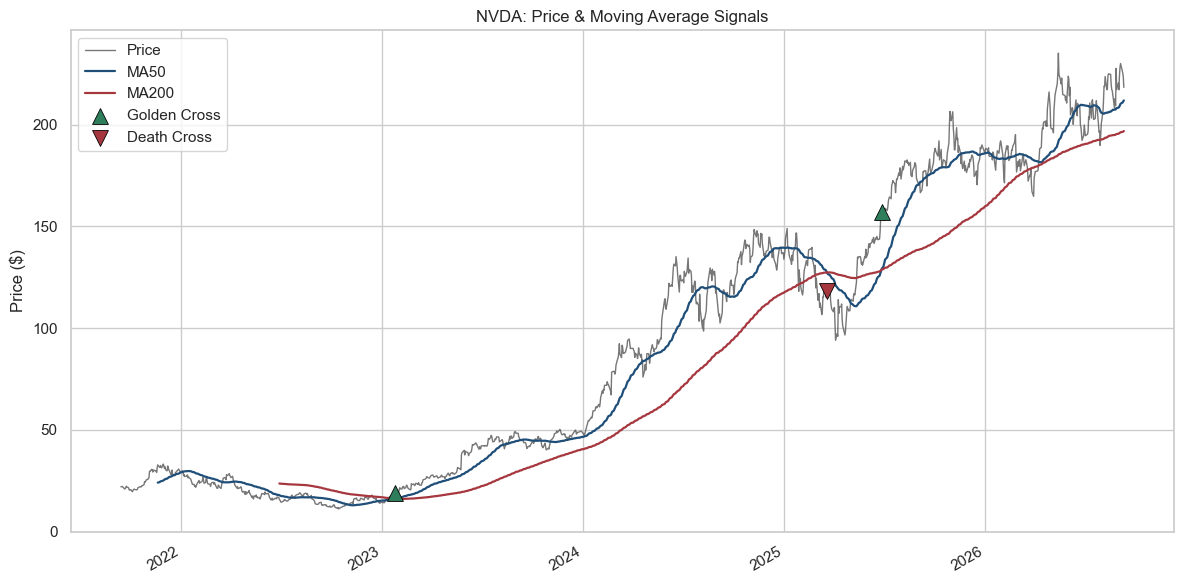

In [5]:
moving_averages = signals.calculate_moving_averages(prices, MA_SHORT, MA_LONG)
crossover_events = signals.detect_crossovers(moving_averages)

CHART_TICKER = "NVDA"

price = moving_averages[(CHART_TICKER, "Price")]
short_ma = moving_averages[(CHART_TICKER, "MA_Short")]
long_ma = moving_averages[(CHART_TICKER, "MA_Long")]

ticker_events = crossover_events[crossover_events["Ticker"] == CHART_TICKER]
golden_events = ticker_events[ticker_events["Signal"] == "Golden Cross"]
death_events = ticker_events[ticker_events["Signal"] == "Death Cross"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(price.index, price, color="#555555", linewidth=1.0, alpha=0.8, label="Price")
ax.plot(short_ma.index, short_ma, color="#1f4e79", linewidth=1.6, label=f"MA{MA_SHORT}")
ax.plot(long_ma.index, long_ma, color="#a6373f", linewidth=1.6, label=f"MA{MA_LONG}")

if not golden_events.empty:
    ax.scatter(golden_events["Date"], golden_events["Price"], marker="^", s=130, color="#2e7d5b", edgecolor="black", linewidth=0.6, zorder=5, label="Golden Cross")
if not death_events.empty:
    ax.scatter(death_events["Date"], death_events["Price"], marker="v", s=130, color="#a6373f", edgecolor="black", linewidth=0.6, zorder=5, label="Death Cross")

ax.set_title(f"{CHART_TICKER}: Price & Moving Average Signals")
ax.set_ylabel("Price ($)")
ax.legend(loc="best")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

In [6]:
golden_count = int((ticker_events["Signal"] == "Golden Cross").sum())
death_count = int((ticker_events["Signal"] == "Death Cross").sum())

if ticker_events.empty:
    explanation = (
        f"No Golden Cross or Death Cross events occurred for {CHART_TICKER} within this sample "
        f"period - the {MA_SHORT}-day and {MA_LONG}-day moving averages did not cross."
    )
else:
    most_recent = ticker_events.iloc[-1]
    most_recent_signal = most_recent["Signal"]
    most_recent_date = most_recent["Date"].date()
    explanation = (
        f"Over this period, {CHART_TICKER} experienced {golden_count} Golden Cross event(s) and "
        f"{death_count} Death Cross event(s). The most recent was a **{most_recent_signal}** "
        f"on {most_recent_date}."
    )

display(Markdown(explanation))

Over this period, NVDA experienced 2 Golden Cross event(s) and 1 Death Cross event(s). The most recent was a **Golden Cross** on 2025-06-27.

## Crossover Event History

The full set of crossover events across all tickers, already sorted chronologically by
`detect_crossovers()`. To keep the notebook readable, only the most recent events are shown if
the full history is long.

In [7]:
MAX_EVENTS_SHOWN = 15

events_display = crossover_events[["Date", "Ticker", "Signal", "Price"]].copy()
events_display["Date"] = events_display["Date"].dt.date
events_display["Price"] = events_display["Price"].map(lambda v: f"${v:,.2f}")

if len(events_display) > MAX_EVENTS_SHOWN:
    print(f"Showing the most recent {MAX_EVENTS_SHOWN} of {len(events_display)} total crossover "
          "events across all tickers.")
    display(events_display.tail(MAX_EVENTS_SHOWN))
else:
    print(f"All {len(events_display)} crossover event(s) across all tickers.")
    display(events_display)

Showing the most recent 15 of 21 total crossover events across all tickers.


,Date,Ticker,Signal,Price
6,2023-09-14,XOM,Golden Cross,$107.40
7,2023-12-06,XOM,Death Cross,$90.63
8,2024-03-27,XOM,Golden Cross,$106.11
9,2024-12-13,LLY,Death Cross,$779.51
10,2025-01-03,XOM,Death Cross,$102.00
11,2025-03-20,NVDA,Death Cross,$118.23
12,2025-04-22,AMZN,Death Cross,$173.18
13,2025-06-27,NVDA,Golden Cross,$157.36
14,2025-07-08,AMZN,Golden Cross,$219.36
15,2025-08-11,XOM,Golden Cross,$101.90


## Backtest Methodology

The approved backtest (`backtest_moving_average_signal()`, used internally by
`create_backtest_summary()` below) applies a simple long/flat rule per ticker:

- The strategy **holds the asset** (position = 1) on any day where the short moving average is
  above the long moving average, and is **flat / out of the market** (position = 0) otherwise.
- The position is **shifted by one trading day** before being applied to returns, so the return
  on day *t* only ever uses the position that was already known at the close of day *t-1* - this
  avoids look-ahead bias.
- **Transaction costs, taxes, bid/ask slippage, and short selling are not modeled.** The strategy
  can only be long or flat; it never shorts the asset, and every position change is assumed to
  execute at the recorded close price with no friction.

This is a simplified, educational backtest of a single technical rule, not a production trading
strategy or an investment recommendation.

## Backtest Summary

The approved `create_backtest_summary()` function compares buy & hold against the moving-average
strategy for every ticker, reusing the project's existing return, volatility, and drawdown
formulas (`src.metrics`) rather than recomputing them here.

In [8]:
backtest_summary = signals.create_backtest_summary(prices, MA_SHORT, MA_LONG)

backtest_display = backtest_summary.copy()
for column in backtest_display.columns:
    backtest_display[column] = backtest_display[column].map(lambda v: f"{v:.1%}")
backtest_display

,Buy & Hold Total Return,Strategy Total Return,Buy & Hold Annualized Return,Strategy Annualized Return,Buy & Hold Annualized Volatility,Strategy Annualized Volatility,Buy & Hold Max Drawdown,Strategy Max Drawdown
Ticker,,,,,,,,
NVDA,890.1%,754.4%,58.6%,53.9%,52.1%,38.8%,-66.3%,-28.4%
JPM,150.6%,157.3%,20.3%,20.9%,24.4%,19.4%,-38.8%,-24.4%
AMZN,45.7%,28.0%,7.9%,5.1%,36.5%,24.7%,-55.7%,-42.8%
LLY,393.8%,179.7%,37.9%,23.0%,32.8%,25.1%,-34.5%,-24.1%
XOM,255.6%,53.4%,29.1%,9.0%,26.7%,20.2%,-20.5%,-30.2%


## Buy & Hold vs Strategy Comparison

Total return by ticker, buy & hold versus the moving-average strategy, using the total-return
values already computed by `create_backtest_summary()` above (not recomputed).

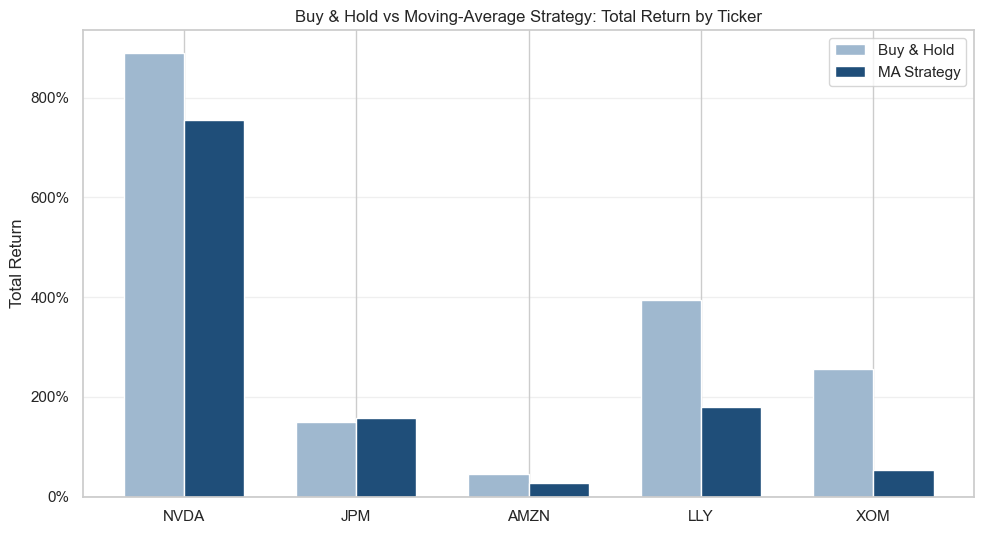

In [9]:
tickers_ordered = backtest_summary.index.tolist()
x_pos = np.arange(len(tickers_ordered))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x_pos - bar_width / 2, backtest_summary["Buy & Hold Total Return"], width=bar_width, color="#9fb8cf", label="Buy & Hold")
ax.bar(x_pos + bar_width / 2, backtest_summary["Strategy Total Return"], width=bar_width, color="#1f4e79", label="MA Strategy")

ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(tickers_ordered)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_ylabel("Total Return")
ax.set_title("Buy & Hold vs Moving-Average Strategy: Total Return by Ticker")
ax.legend(loc="best")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

## Key Findings

The summary below is generated programmatically from the backtest results computed above, so it
remains valid if the underlying cached dataset is refreshed - no ticker-specific conclusions are
hardcoded.

In [10]:
finding_lines = []
for ticker, row in backtest_summary.iterrows():
    return_diff = row["Strategy Total Return"] - row["Buy & Hold Total Return"]
    drawdown_diff = row["Strategy Max Drawdown"] - row["Buy & Hold Max Drawdown"]
    return_improved = return_diff > 0
    drawdown_improved = drawdown_diff > 0  # less negative = smaller (better) max drawdown

    if drawdown_improved and not return_improved:
        pattern = (
            f"reduced maximum drawdown by {drawdown_diff:.1%} versus buy & hold, but also reduced "
            f"total return by {abs(return_diff):.1%}"
        )
    elif drawdown_improved and return_improved:
        pattern = (
            f"improved both total return (+{return_diff:.1%}) and maximum drawdown "
            f"({drawdown_diff:+.1%}) versus buy & hold"
        )
    elif not drawdown_improved and return_improved:
        pattern = (
            f"improved total return (+{return_diff:.1%}) despite a larger maximum drawdown "
            f"({drawdown_diff:+.1%}) than buy & hold"
        )
    else:
        pattern = (
            f"did not improve on buy & hold over this period, with total return {return_diff:+.1%} "
            f"and maximum drawdown {drawdown_diff:+.1%} relative to buy & hold"
        )

    finding_lines.append(f"- **{ticker}**: the moving-average strategy {pattern}.")

findings = (
    "\n".join(finding_lines)
    + "\n\n"
    + "These results describe this specific historical sample only. A smaller maximum drawdown "
    "does not guarantee a better risk-adjusted outcome, and historical strategy performance is "
    "not a prediction of future performance."
)

display(Markdown(findings))

- **NVDA**: the moving-average strategy reduced maximum drawdown by 37.9% versus buy & hold, but also reduced total return by 135.6%.
- **JPM**: the moving-average strategy improved both total return (+6.7%) and maximum drawdown (+14.3%) versus buy & hold.
- **AMZN**: the moving-average strategy reduced maximum drawdown by 12.9% versus buy & hold, but also reduced total return by 17.7%.
- **LLY**: the moving-average strategy reduced maximum drawdown by 10.3% versus buy & hold, but also reduced total return by 214.1%.
- **XOM**: the moving-average strategy did not improve on buy & hold over this period, with total return -202.2% and maximum drawdown -9.7% relative to buy & hold.

These results describe this specific historical sample only. A smaller maximum drawdown does not guarantee a better risk-adjusted outcome, and historical strategy performance is not a prediction of future performance.

## Limitations

- **Backward-looking signals**: moving averages and crossovers are calculated purely from past
  prices; they do not anticipate future price movements.
- **Sensitivity to window choice**: results depend on the specific `MA_SHORT` / `MA_LONG` window
  lengths used here (50/200 by default in `config.py`); different windows can produce materially
  different signals and backtest outcomes.
- **Transaction costs and slippage are not modeled**: the backtest assumes frictionless entry and
  exit at the recorded close price, with no commissions, spread, or market impact.
- **Whipsaw risk**: in choppy or range-bound markets, the short and long moving averages can cross
  back and forth repeatedly, generating frequent false signals and reducing the reliability of any
  single crossover event.
- **Past performance does not imply future performance**: nothing in this notebook predicts how
  any of these tickers, or this strategy, will behave going forward.